## Similitud - Análisis

Se responde **P2 — Fraccionamiento** con los resultados de `a_minhash` a `d_entidades`:

> ¿Hay procesos **casi idénticos** de una **misma entidad**, en **fechas cercanas** y con **montos bajos**, que sugieran dividir una compra para **evadir un método más exigente**?

### Imports

In [1]:
import os, socket
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 90); pd.set_option("display.width", 200)

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
sim_dir = proyecto / "02_Similitud" / "temp"
out_dir = sim_dir / "e_analisis"
out_dir.mkdir(parents=True, exist_ok=True)

- Funciones

Parámetros compartidos de `02_Similitud/funciones.ipynb`

In [3]:
ruta_funciones = str(proyecto / "02_Similitud" / "funciones.ipynb")
%run $ruta_funciones

- Figuras y tablas

In [4]:
def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()


def guardar_tabla(df, nombre):
    # parquet para el siguiente notebook + json para la página web
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()


def dirs_salida(out_dir):
    fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
    for d in (fig_dir, tab_dir, web_dir):
        d.mkdir(parents=True, exist_ok=True)
    return fig_dir, tab_dir, web_dir


fig_dir, tab_dir, web_dir = dirs_salida(out_dir)

- Spark

In [5]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("similitud-analisis")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.sql.autoBroadcastJoinThreshold", "-1")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [ ]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

---
### 1. Carga de resultados

In [7]:
def leer(nb, tabla):
    ruta = sim_dir / nb / "tablas" / tabla
    assert ruta.exists(), f"Corre {nb}.ipynb (Run All) antes que este notebook."
    return spark.read.parquet(str(ruta)).toPandas()

repres   = leer("a_minhash", "representacion")
res_a    = leer("a_minhash", "resumen")
configs  = leer("b_lsh", "configs_br")
res_b    = leer("b_lsh", "resumen")
por_mes  = leer("c_pares", "pares_por_mes")
embudo   = leer("d_entidades", "embudo_p2")
res_d    = leer("d_entidades", "resumen")
ranking  = leer("d_entidades", "ranking")
pares_p2 = spark.read.parquet(str(sim_dir / "d_entidades" / "pares_p2")).cache()
procesos = spark.read.parquet(str(proyecto / "data" / "final")).select("ocid", "entidad", "fecha", "monto_final", "metodo_detalle", "descripcion")
print(f"Pares: {pares_p2.count():,} | entidades en el ranking: {len(ranking)}")

Pares: 131,473 | entidades en el ranking: 30


### 2. La técnica

In [8]:
elegida = configs[(configs["b"] == B) & (configs["r"] == R)].iloc[0]
tecnica = pd.DataFrame([
    {"etapa": "Representación", "resultado": f"shingles k=5 de `texto` (mediana {int(repres.loc[repres.representacion == 'k=5', 'tamano_mediano'].iloc[0])} por proceso)"},
    {"etapa": "MinHash", "resultado": f"T={T}: error medio {res_a['mae_minhash'].iloc[0]:.3f} vs Jaccard exacto (teórico {res_a['error_teorico'].iloc[0]:.3f})"},
    {"etapa": "LSH (mes de prueba)", "resultado": f"(b, r) = ({B}, {R}): {int(elegida['candidatos']):,} candidatos vs {int(res_b['pares_fuerza_bruta'].iloc[0]):,} de fuerza bruta "
                                              f"(−{1 - elegida['candidatos'] / res_b['pares_fuerza_bruta'].iloc[0]:.0%}); recall {elegida['recall']:.0%}, precision {elegida['precision']:.2f}"},
    {"etapa": "LSH (36 meses)", "resultado": f"{int(por_mes['candidatos'].sum()):,} candidatos → {int(por_mes['pares_90'].sum()):,} pares ≥ {UMBRAL} en {por_mes['seg'].sum():.0f} s"},
])
tecnica

,etapa,resultado
0,Representación,shingles k=5 de `texto` (mediana 172 por proceso)
1,MinHash,T=100: error medio 0.031 vs Jaccard exacto (teórico 0.050)
2,LSH (mes de prueba),"(b, r) = (10, 10): 10,209 candidatos vs 212,632 de fuerza bruta (−95%); recall 100%, p..."
3,LSH (36 meses),"163,482 candidatos → 131,473 pares ≥ 0.9 en 63 s"


- Shingles de 5 caracteres: equilibrio entre similitud falsa (k=3) y casi-duplicados perdidos (k=7); conserva dígitos y palabras cortas que las palabras sueltas pierden

- MinHash con 100 hashes estima el Jaccard con error medio de 0.031, bajo el teórico de 0.05

- LSH con `(10, 10)` evita el 95% de las comparaciones y no pierde ningún par real en el mes de prueba; los 36 meses se procesan en ~1 min

### 3. Respuesta a P2

In [9]:
ES_OEFA = F.col("entidad").contains("FISCALIZACION AMBIENTAL")   # OEFA: aporta el 83% de los pares, se mide aparte
cols = [F.lit(True), F.col("n1"), F.col("n2"), F.col("n3"), F.col("n4")]
def procesos_nivel(df):
    return [df.where(c).select(F.explode(F.array("ocid_1", "ocid_2"))).distinct().count() for c in cols]

embudo["procesos_oefa"] = procesos_nivel(pares_p2.where(ES_OEFA))
embudo["procesos_sin_oefa"] = procesos_nivel(pares_p2.where(~ES_OEFA))
embudo["entidades_sin_oefa"] = [pares_p2.where(~ES_OEFA & c).select("entidad").distinct().count() for c in cols]
embudo[["nivel", "procesos", "procesos_oefa", "procesos_sin_oefa", "entidades_sin_oefa", "pct_procesos"]]

,nivel,procesos,procesos_oefa,procesos_sin_oefa,entidades_sin_oefa,pct_procesos
0,"1. casi idénticos, misma entidad, ≤ 15 días",37094,3016,34078,2338,15.72
1,2. sin casi-duplicados del EDA,31592,2966,28626,2232,13.39
2,3. + montos bajos (< 200k),10590,2962,7628,1255,4.49
3,4. + la suma salta de tramo,4847,1398,3449,859,2.05
4,5. + método poco usado en el tramo de la suma,1549,1388,161,32,0.66


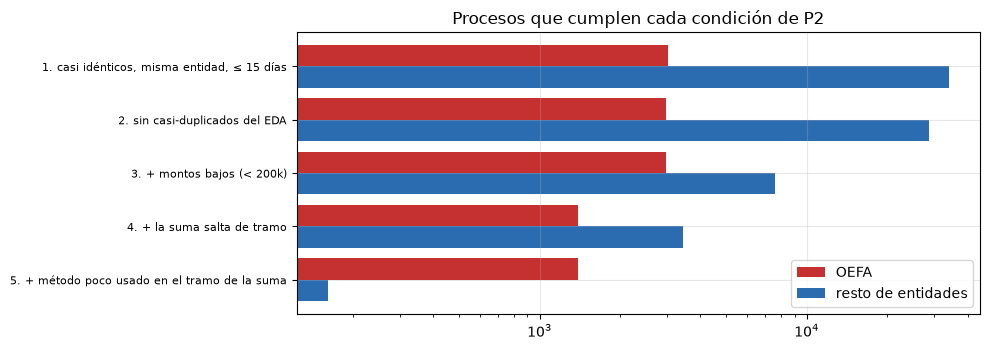

In [10]:
y = np.arange(len(embudo))[::-1]
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.barh(y + .2, embudo["procesos_oefa"], .4, color="#c53030", label="OEFA")
ax.barh(y - .2, embudo["procesos_sin_oefa"], .4, color="#2b6cb0", label="resto de entidades")
ax.set_yticks(y); ax.set_yticklabels(embudo["nivel"], fontsize=8); ax.set_xscale("log"); ax.legend()
ax.set_title("Procesos que cumplen cada condición de P2")
mostrar_fig("embudo_oefa")

- **Sí hay procesos casi idénticos de una misma entidad en fechas cercanas: 37,094 (15.7%)**. Pero cumplir todas las condiciones de P2 es raro: **1,549 procesos (0.66%)**

- La condición que más recorta es **montos bajos** (31,592 → 10,590): la mayoría de los casi-duplicados son compras repetidas de montos medianos o grandes, no compras partidas

- **OEFA es el 90% del patrón completo** (1,388 de 1,549 procesos). Sin OEFA quedan 161 procesos en 32 entidades

- El método que cambia al juntar los montos es casi siempre **Régimen Especial** (OEFA) o **Convenio** (unidades de proyectos). Con Adjudicación Simplificada, el método más común, dividir la compra no cambia el método

#### a. Sensibilidad a los parámetros

De `d_entidades` §7: se cambia un parámetro a la vez

In [11]:
variacion = leer("d_entidades", "variacion_p2")
variacion[["parametro", "valor", "pct_casi_identicos", "procesos_p2", "pct_p2", "pct_p2_oefa", "entidades_p2_sin_oefa"]]

,parametro,valor,pct_casi_identicos,procesos_p2,pct_p2,pct_p2_oefa,entidades_p2_sin_oefa
0,elegido,—,15.72,1549,0.66,89.6,32
1,UMBRAL,0.8,20.00,1724,0.73,81.3,39
2,UMBRAL,0.95,14.47,1483,0.63,93.6,24
3,VENTANA_DIAS,7,13.37,1395,0.59,91.5,25
4,VENTANA_DIAS,28,20.75,1592,0.67,87.5,38
5,CORTE_BAJO,100000,15.72,1517,0.64,91.5,20
6,CORTE_BAJO,500000,15.72,1549,0.66,89.6,32
7,CUOTA_RELATIVA,0.3,15.72,1523,0.65,91.1,23
8,CUOTA_RELATIVA,0.7,15.72,1549,0.66,89.6,32


- El % de procesos casi idénticos depende de la definición (13%–21% según umbral y ventana)

- El patrón completo de P2 se mantiene entre 0.59% y 0.73% y OEFA aporta entre 81% y 94% en todas las variaciones: la respuesta a P2 no depende de los parámetros elegidos

### 4. Casos concretos

#### a. OEFA

In [12]:
oefa = pares_p2.where(ES_OEFA & F.col("n4"))
(oefa.groupBy(F.date_format("fecha_1", "yyyy-MM").alias("mes")).agg(F.count("*").alias("pares"), F.countDistinct("ocid_1").alias("procesos"))
     .orderBy(F.desc("pares")).show(5))
(oefa.groupBy("descripcion_1").agg(F.count("*").alias("pares"), F.expr("percentile_approx(monto_final_1, array(0.1, 0.5, 0.9))").alias("monto p10/p50/p90"))
     .orderBy(F.desc("pares")).show(5, truncate=60))

+-------+-----+--------+
|    mes|pares|procesos|
+-------+-----+--------+
|2025-03|17355|     383|
|2025-02| 4450|     229|
|2023-05|  731|     104|
|2024-06|  649|     115|
|2024-10|  477|     100|
+-------+-----+--------+
only showing top 5 rows



+--------------------------------------------------+-----+---------------------------+
|                                     descripcion_1|pares|          monto p10/p50/p90|
+--------------------------------------------------+-----+---------------------------+
|                 SERVICIO DE SUPERVISIÓN AMBIENTAL|14778|[16000.0, 36000.0, 48000.0]|
|       SERVICIO DE EVALUACIÓN EN TEMAS AMBIENTALES| 6999|[24000.0, 48000.0, 48000.0]|
|TERCERO SUPERVISOR TITULADO - INGENIERIA AMBIENTAL|  682|[18000.0, 30000.0, 48000.0]|
|           TERCERO FISCALIZADOR TITULADO - DERECHO|  461|[18000.0, 24000.0, 40000.0]|
|           TERCERO SUPERVISOR INGENIERÍA AMBIENTAL|  425|[24000.0, 32000.0, 42000.0]|
+--------------------------------------------------+-----+---------------------------+
only showing top 5 rows



- El patrón completo de OEFA se concentra en marzo y febrero de 2025 (383 y 229 procesos): convocatorias masivas el mismo día con la misma descripción

- Son servicios de **terceros** (supervisión, evaluación y fiscalización ambiental) por Régimen Especial, con montos de S/ 16k–48k

- Por su forma se parece más a la contratación masiva de personas para servicios que a una compra partida: cada proceso es un profesional distinto. La técnica no puede distinguirlo; hay que revisarlo en el SEACE

#### b. Par de texto distinto con el patrón completo

In [13]:
def m(x):
    return f"S/ {x:,.0f}" if x is not None else "sin monto"

def pct(x):
    return f"{100 * x:.1f}%" if x is not None else "–"

def mostrar_par(r):
    print(f"{r['entidad']} | {r['metodo_1']}")
    print(f"  {r['fecha_1']:%Y-%m-%d} → {r['fecha_2']:%Y-%m-%d} ({r['dias_diferencia']} días) | Jaccard {r['jaccard']} | MinHash {r['minhash_sim']}")
    print(f"  {m(r['monto_final_1'])} + {m(r['monto_final_2'])} = {m(r['monto_suma'])} ({r['tramo_1']} + {r['tramo_2']} → {r['tramo_suma']})")
    print(f"  cuota del método: {pct(r['cuota_1'])} en su tramo → {pct(r['cuota_1_suma'])} en el de la suma")
    print(f"  [1] {r['descripcion_1'][:160]}\n  [2] {r['descripcion_2'][:160]}\n")

for r in pares_p2.where(~ES_OEFA & F.col("n4") & ~F.col("texto_identico")).orderBy(F.desc("jaccard"), "dias_diferencia").limit(2).collect():
    mostrar_par(r)

UNIVERSIDAD NACIONAL DEL SANTA | CONVENIO
  2025-09-29 → 2025-10-13 (14 días) | Jaccard 1.0 | MinHash 1.0
  S/ 30,000 + S/ 25,356 = S/ 55,356 (1_<50k + 1_<50k → 2_50k-200k)
  cuota del método: 13.4% en su tramo → 1.7% en el de la suma
  [1] LA ADQUISICIÓN DE MATERIALES DE VIDRIO VARIOS PARA EL PROGRAMA DOCTORADO EN INGENIERÍA AGROINDUSTRIAL MENCIÓN TRANSFORMACIÓN AVANZADA DE GRANOS Y TUBÉRCULOS AND
  [2] LA ADQUISICIÓN DE MATERIALES DE VIDRIO VARIOS PARA EL PROGRAMA DOCTORADO EN INGENIERÍA AGROINDUSTRIAL MENCIÓN TRANSFORMACIÓN AVANZADA DE GRANOS Y TUBÉRCULOS AND

MEJORA DE LA CALIDAD DE SERVICIOS REGISTRALES - RENIEC | CONVENIO
  2023-04-17 → 2023-04-17 (0 días) | Jaccard 0.993 | MinHash 1.0
  S/ 37,500 + S/ 37,500 = S/ 75,000 (1_<50k + 1_<50k → 2_50k-200k)
  cuota del método: 13.4% en su tramo → 1.7% en el de la suma
  [1] SERVICIO ESPECIALIZADO EN IMPLEMENTACIÓN DE SISTEMAS ELECTRICOS EN LOS LOCALES DE RENIEC PARA ASEGURAR SU FUNCIONAMIENTO OPTIMO - CONSULTOR 01
  [2] SERVICIO ESPECI

- Universidad Nacional del Santa: la misma compra de material de vidrio para un doctorado, en dos procesos a 14 días, por S/ 30,000 y S/ 25,356. Juntos suman S/ 55,356, el tramo donde Convenio pasa de 13.4% a 1.7% de uso

- RENIEC (proyecto de mejora registral): dos consultorías idénticas de S/ 37,500 el mismo día; juntas, S/ 75,000

- Son los casos que mejor calzan con P2: montos bajos, misma descripción y una suma que cambiaría el método habitual

#### c. Instituto vial: rate alto sin patrón de P2

In [14]:
IVP = "INSTITUTO VIAL PROVINCIAL DE PASCO"   # el de mayor rate (67%) entre las entidades viales con ≥ 50 procesos
ivp = pares_p2.where(F.col("entidad").startswith(IVP))
ivp.agg(F.count("*").alias("pares"), F.avg(F.col("montos_bajos").cast("int")).alias("frac_montos_bajos"),
        F.avg(F.col("salta_tramo").cast("int")).alias("frac_salta_tramo"), F.avg(F.col("metodo_menos_exigente").cast("int")).alias("frac_metodo")).show()
ivp.groupBy("metodo_1", "tramo_1").count().orderBy(F.desc("count")).show(4, truncate=40)
mostrar_par(ivp.orderBy(F.desc("jaccard"), "dias_diferencia").first())

+-----+------------------+-------------------+-----------+
|pares| frac_montos_bajos|   frac_salta_tramo|frac_metodo|
+-----+------------------+-------------------+-----------+
|   61|0.5901639344262295|0.09836065573770492|        0.0|
+-----+------------------+-------------------+-----------+



+-------------------------+-----------+-----+
|                 metodo_1|    tramo_1|count|
+-------------------------+-----------+-----+
|ADJUDICACIÓN SIMPLIFICADA| 2_50k-200k|   54|
|ADJUDICACIÓN SIMPLIFICADA|     1_<50k|    4|
|ADJUDICACIÓN SIMPLIFICADA|0_sin_monto|    2|
|ADJUDICACIÓN SIMPLIFICADA|  3_200k-1M|    1|
+-------------------------+-----------+-----+

INSTITUTO VIAL PROVINCIAL DE PASCO - IVP-PASCO | ADJUDICACIÓN SIMPLIFICADA
  2024-04-10 → 2024-04-10 (0 días) | Jaccard 1.0 | MinHash 1.0
  S/ 47,520 + S/ 47,520 = S/ 95,040 (1_<50k + 1_<50k → 2_50k-200k)
  cuota del método: 24.9% en su tramo → 50.2% en el de la suma
  [1] "CONTRATACION DE SERVICIO DE MANTENIMIENTO RUTINARIO DEL CAMINO VECINAL NO PAVIMENTADO, TRAMO: EMP. PA-598 (CHACACANCHA) - PTA. DE CARRETERA L=6.600 KM UBICADO 
  [2] "CONTRATACION DE SERVICIO DE MANTENIMIENTO RUTINARIO DEL CAMINO VECINAL NO PAVIMENTADO, TRAMO: EMP. PA-598 (CHACACANCHA) - PTA. DE CARRETERA L=6.600 KM UBICADO 



- El IVP Pasco tiene 67% de sus procesos en algún par, pero ninguno con el patrón completo: son mantenimientos rutinarios de tramos de carretera por Adjudicación Simplificada (54 de 61 pares)

- Aunque la suma salte de tramo (S/ 124k + S/ 124k = S/ 248k), Adjudicación Simplificada se usa igual en ambos tramos (50% y 48%): dividir no evita un método más exigente

- Un rate alto de similitud no basta para hablar de fraccionamiento: hace falta que la división cambie el método

### 5. Limitaciones

- **Ser similar no prueba fraccionamiento:** un par puede ser una republicación, varios lotes de una misma obra, servicios recurrentes legítimos o, como en OEFA, la contratación de varias personas para el mismo servicio

- **Método menos exigente** se mide con la data (cuota del método por tramo), no con los umbrales legales en UIT, que cambian cada año y por tipo de objeto

- La ventana de 15 días, el umbral de 0.90, el corte de S/ 200k y la cuota relativa de 0.5 son decisiones del equipo: cambian el % de casi idénticos (13%–21%), pero no la respuesta a P2 (§3.a)

- `monto_sospechoso` suma cada proceso una sola vez; el antiguo `monto_involucrado` sumaba por par y contaba muchas veces el mismo proceso

---
### 6. Síntesis

- **Respuesta a P2:** sí existen procesos casi idénticos de una misma entidad en fechas cercanas (1 de cada 6), pero el patrón completo de fraccionamiento (montos bajos y una suma que cambiaría el método) es raro: 0.66% de los procesos

- **Un caso domina:** OEFA aporta el 83% de los pares y el 90% del patrón completo, con contrataciones masivas de terceros por Régimen Especial

- **Fuera de OEFA**, el patrón aparece en 32 entidades y 161 procesos, casi siempre por Convenio en unidades de proyectos: es la lista más útil para auditar

- **La técnica escala:** MinHash + LSH procesa los 3 años en ~1 min sin perder pares, frente a la fuerza bruta que en un solo mes ya compara 212 mil pares

### 7. Escritura de resultados

Tablas en `temp/e_analisis/tablas` (parquet) y `web/` (json)

In [15]:
tablas = {"tecnica": tecnica, "embudo_p2_oefa": embudo}
escritos = {nombre: guardar_tabla(df, nombre) for nombre, df in tablas.items()}
print(f"Escrito en temp/e_analisis/: {', '.join(escritos)}")

Escrito en temp/e_analisis/: tecnica, embudo_p2_oefa


#### a. Verificación

In [16]:
for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json) | {len(figs)} figuras: {', '.join(figs)}")

OK: 2 tablas (parquet + json) | 1 figuras: embudo_oefa


---
### 8. Cerrar sesión

In [17]:
spark.stop()